# 2.02 Calculating trace element concentrations with mineral-specific partition coefficients (1 lithology)

Simon Matthews (simonm@hi.is), February 2025

---

This notebook is intended to be a starting point for setting up calculations of magma trace element concentrations using mineral-specific partition coefficients combined with mineral proportions from a phase diagram. This template is for melting a melting containing a single lithology, see other templates for a starting point for multi-lithology melting.

Though I have added some description of each step, to find a more comprehensive account of why the calculation is structured the way it is see the pyMelt documentation and tutorials.

## 1. Preliminaries

First import the modules required:

In [1]:
import pyMelt as m
import numpy as np
import matplotlib.pyplot as plt

Then set up a lithology object, in this case a lherzolite lithology, then make a mantle from it:

In [2]:
lz = m.lithologies.matthews.klb1()
mantle = m.mantle([lz], [1.0], ['lz'])

## 2. Melt the mantle

So that we can see the result of garnet-present melting, I will use a $T_p$ of 1480˚C:

In [3]:
column = mantle.adiabaticMelt(1480.0)

(<Figure size 640x480 with 2 Axes>,
 array([<AxesSubplot:xlabel='Temperature (°C)', ylabel='Pressure (GPa)'>,
        <AxesSubplot:xlabel='Melt Fraction'>], dtype=object))

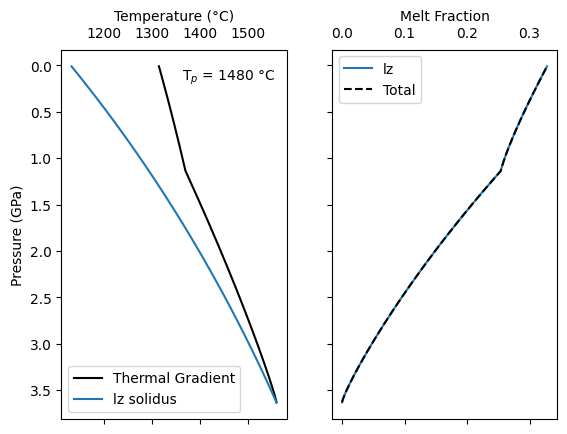

In [4]:
column.plot()

We need to know the mineral proportions at each step of melting:

In [5]:
column.calculateMineralProportions()

And we make a quick plot showing them:

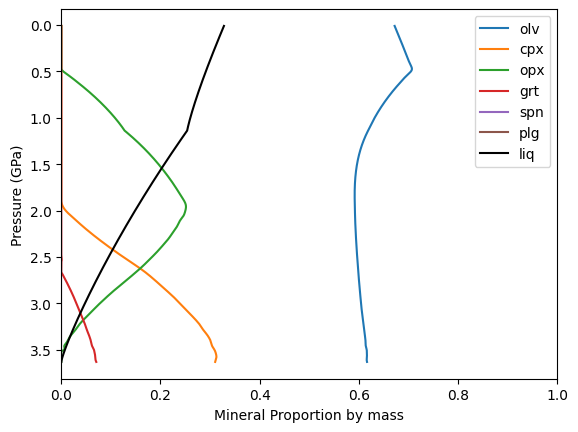

In [6]:
fig, ax = plt.subplots()

for mineral in column.mantle.lithologies[0].phaseDiagram.minerals:
    ax.plot(column.composition['lz'][mineral],
            column.composition['lz']['P'],
            label=mineral)

ax.plot(column.composition['lz']['F'],
        column.composition['lz']['P'],
        label='liq', c='k')

ax.invert_yaxis()
ax.legend()

ax.set_xlim(0, 1.0)

ax.set_ylabel('Pressure (GPa)')
ax.set_xlabel('Mineral Proportion by mass')

plt.show()

## 3. Set up trace element calculation

The default partition coefficients for each mineral and trace element are shown below. For the first example, we will use these. See further below for an example of setting your own partition coefficients.

In [7]:
m.chemistry.defaultD

,olv,cpx,opx,plg,grt,spn
Rb,0.000300,0.0004,0.000200,0.030,0.00020,0.0001
Ba,0.000005,0.0004,0.000006,0.330,0.00007,0.0001
Th,0.000050,0.0059,0.002000,0.050,0.00900,0.0000
U,0.000380,0.0094,0.002000,0.110,0.02800,0.0000
Nb,0.000500,0.0150,0.004000,0.010,0.01500,0.0000
Ta,0.000500,0.0150,0.004000,0.000,0.01500,0.0000
La,0.000500,0.0490,0.003100,0.270,0.00100,0.0100
Ce,0.000500,0.0800,0.004000,0.200,0.00500,0.0100
Pb,0.003000,0.0120,0.009000,0.360,0.00500,0.0000
Pr,0.000800,0.1260,0.004800,0.170,0.01400,0.0100


We must set the concentration of trace elements in the mantle source. This can be done either by supplying a pandas DataFrame, or by setting up nested dictionaries, as shown here. This is the composition of "Average DMM" from Workman & Hart (2005).

In [8]:
c0 = {'lz': {
    'Rb': 0.05,
    'Ba': 0.563,
    'Th': 0.0079,
    'U':  0.0032,
    'Nb': 0.1485,
    'Ta': 0.0096,
    'La': 0.192,
    'Ce': 0.550,
    'Pb': 0.018,
    'Pr': 0.107,
    'Nd': 0.581,
    'Sr': 7.664,
    'Zr': 5.082,
    'Hf': 0.157,
    'Sm': 0.239,
    'Eu': 0.096,
    'Gd': 0.358,
    'Tb': 0.070,
    'Dy': 0.505,
    'Ho': 0.115,
    'Y':  3.328,
    'Er': 0.348,
    'Yb': 0.365,
    'Lu': 0.058,
}}

## 4. Run the trace element calculation

Now we feed the mantle trace element concentrations into the calculation. We can also set a residual porosity during melting (by default it is set at 0.0):

In [9]:
column.calculateTraceElements(c0=c0,
                              porosity=0.005)

We can plot the instantaneous melt compositions, for example:

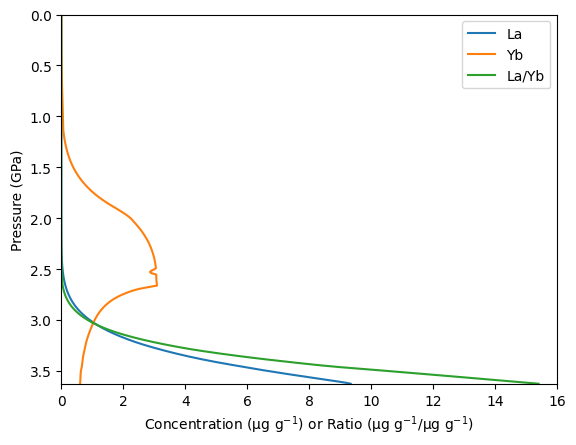

In [10]:
fig, ax = plt.subplots()

ax.plot(column.composition['lz'].liq_La, 
        column.P,
        label='La')
ax.plot(column.composition['lz'].liq_Yb, 
        column.P,
        label='Yb')
ax.plot(column.composition['lz'].liq_La/column.composition['lz'].liq_Yb, 
        column.P, 
        label='La/Yb')

ax.invert_yaxis()
ax.legend()
ax.set_xlim(0, 16)
ax.set_ylim(np.max(column.P), 0.0)

ax.set_xlabel('Concentration (µg g$^{-1}$) or Ratio (µg g$^{-1}$/µg g$^{-1}$)')

ax.set_ylabel('Pressure (GPa)')

plt.show()

We could also save them as a csv file:

In [11]:
column.composition['lz'].to_csv('lz_te_concs.csv')

## 5. Calculate aggregate melt composition

Next we can calculate the concentrations in the aggregate melt. This requires making some assumptions about the melting region corresponding to the geodynamic setting. Here we assume we are melting at a mid-ocean ridge. Considering the high $T_p$ value used above, this might be representative of a location like Iceland.

For other geodynamic settings, see the code given in other templates.

In [12]:
mor = m.geosettings.spreadingCentre(column)

/workspaces/pyMelt/pyMelt/geosettings.py:509: RuntimeWarning: invalid value encountered in true_divide
  cm = cm / norm


We can look at these melt concentrations by printing the result:

*note that this is a little indirect at the moment- I need to fix this*

In [13]:
for name, conc in mor.chemistry.iteritems():
    if name[:3] == 'liq':
        print(f'{name[4:]}: {conc:.3f}')

Rb: 0.306
Ba: 3.444
Th: 0.048
U: 0.020
Nb: 0.907
Ta: 0.059
La: 1.145
Ce: 3.197
Pb: 0.110
Pr: 0.600
Nd: 3.136
Sr: 44.251
Zr: 27.738
Hf: 0.780
Sm: 1.198
Eu: 0.468
Gd: 1.716
Tb: 0.324
Dy: 2.306
Ho: 0.514
Y: 14.543
Er: 1.497
Yb: 1.506
Lu: 0.235


We can also plot a spider diagram:

(<Figure size 960x720 with 1 Axes>,
 <AxesSubplot:ylabel='Normalised concentration'>)

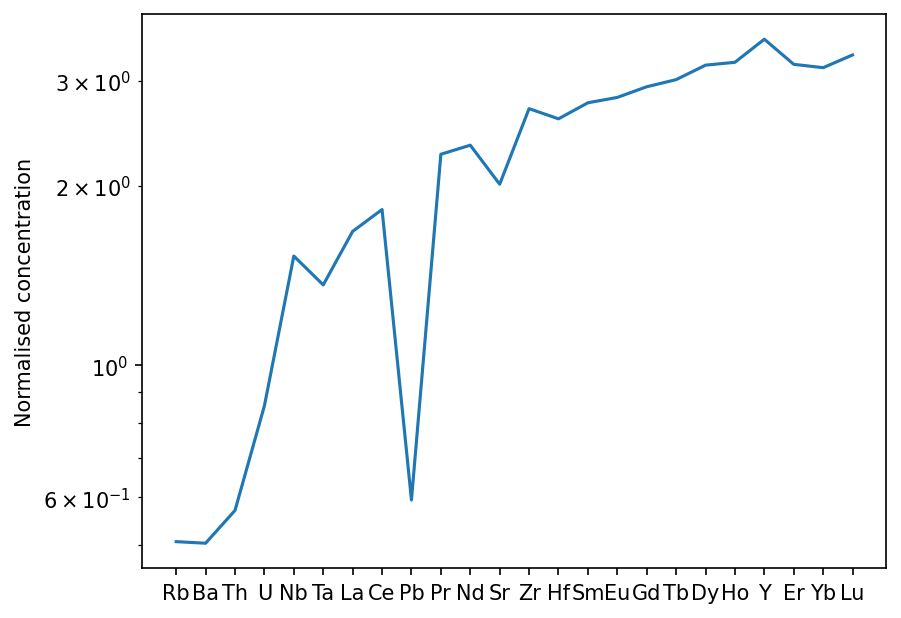

In [15]:
mor.plotSpider()

## 6. References

Workman, R. K., & Hart, S. R. (2005). Major and trace element composition of the depleted MORB mantle (DMM). Earth and Planetary Science Letters, 231(1-2), 53-72.